 # Project description



 Prepare a prototype of a machine learning model for Zyfra. The company develops efficiency solutions for heavy industry.



 The model should predict the amount of gold recovered from gold ore. You have the data on extraction and purification..



 The model will help to optimize the production and eliminate unprofitable parameters.



 You need to:



 1. Prepare the data;

 2. Perform data analysis;

 3. Develop and train a model.



 To complete the project, you may want to use documentation from *pandas*, *matplotlib*, and *sklearn.*

In [3]:
# %%
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt


 # 1. Data preparation

 ### Downloading

In [6]:
# %%
df_train = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_train_new.csv', index_col='date', parse_dates=True)
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_test_new.csv', index_col='date', parse_dates=True)
df_full = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_full_new.csv', index_col='date', parse_dates=True)

df_train.shape, df_test.shape


((14149, 86), (5290, 52))

In [ ]:
# %%
df_train.head()


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,10.128295,7.25,0.988759,8.547551,10.389648,19.529297,34.174427,14.936526,2.534912,7.476074,2.106679,1549.775757,-498.912140,1551.434204,-516.403442,1549.873901,-498.666595,1554.367432,-493.428131,41885.707031,3481.779053,3520.337158,2.838687,6.100378,2.284912,523.546326,55.486599,36.808594,6.486150,11.986616,6.007990,11.836743,6.005818,11.500771,7.101074,28.029297,19.793808,87.107763,5.008018,0.508728,19.154297,1.170244,999.706909,-404.066986,1603.011353,-434.715027,1602.375000,-442.204468,1598.937256,-451.294128,1404.472046,-455.462982,1416.354980,-451.939636,14.500184,4.694824,8.764648,2.606185,25.853109,-498.526489,23.893660,-501.406281,23.961798,-495.262817,21.940409,-499.340973,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.

In [8]:
# %%
df_full = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_full_new.csv', parse_dates=True, index_col='date')


 ### Calculation validity check

In [9]:
# %%
# Check the formula: whether the calculation result matches the provided data.

def recovery_calc(row):
    numerator = row['rougher.output.concentrate_au']*(row['rougher.input.feed_au']-row['rougher.output.tail_au'])
    denominator = row['rougher.input.feed_au']*(row['rougher.output.concentrate_au']-row['rougher.output.tail_au'])
    return numerator/denominator*100

df_formula = df_train.copy()
df_formula['formula'] = df_formula.apply(lambda x: recovery_calc(x), axis=1)

answer = (df_formula['formula'] - df_formula['rougher.output.recovery']).abs().mean()

print('Difference between the expected value and measured value is {}'.format(answer))


Difference between the expected value and measured value is 9.649249696983847e-15


 Therefore, the formula is correct, which is supported by the available data.

 ### Preprocessing (missing values)

In [9]:
#IRA
df_full.isnull().sum()/len(df_full)*100 

final.output.concentrate_ag                   0.005144
final.output.concentrate_pb                   0.005144
final.output.concentrate_sol                  1.085447
final.output.concentrate_au                   0.000000
final.output.recovery                         0.000000
                                                ...   
secondary_cleaner.state.floatbank5_a_level    0.005144
secondary_cleaner.state.floatbank5_b_air      0.005144
secondary_cleaner.state.floatbank5_b_level    0.005144
secondary_cleaner.state.floatbank6_a_air      0.010289
secondary_cleaner.state.floatbank6_a_level    0.005144
Length: 86, dtype: float64

In [10]:
# %%
df_full.isnull().mean().sort_values(ascending=False).head(10)


secondary_cleaner.output.tail_sol           0.089922
rougher.input.floatbank11_xanthate          0.023304
rougher.state.floatbank10_e_air             0.022429
primary_cleaner.output.concentrate_sol      0.019034
secondary_cleaner.state.floatbank2_a_air    0.011317
final.output.concentrate_sol                0.010854
rougher.input.feed_size                     0.007459
primary_cleaner.output.concentrate_pb       0.005967
primary_cleaner.input.xanthate              0.005350
final.output.tail_pb                        0.005196
dtype: float64

 The missing values are few with no missing values in targets. Fill them with previous values.

In [11]:
# %%
df_train = df_train.fillna(method='ffill')
df_test = df_test.fillna(method='ffill')


/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_37421/688988152.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_train = df_train.fillna(method='ffill')
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_37421/688988152.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_test = df_test.fillna(method='ffill')


 ### List of unavailable parameters

In [12]:
# %%
missed_test_columns = set(list(df_train.columns.values))-set(list(df_test.columns.values))
missed_test_columns


{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

 Some calculation and output process characteristics are unavailable in the test set. These parameters are unavailable in the test set because they are impossible to obtain/measure during the technological process.

 # 2. Data analysis

 ### Concentration changes

In [13]:
# %%
steps_template = [
    'rougher.input.feed_{}',
    'rougher.output.concentrate_{}',
    'primary_cleaner.output.concentrate_{}',
    'final.output.concentrate_{}',
]

def plot_concentrate_progress(component):
    steps = [s.format(component) for s in steps_template]
    for step in steps:
        df_full[step].hist(alpha=0.5, bins=20)
    plt.legend(steps)


Text(0.5, 1.0, 'Gold concentration change')

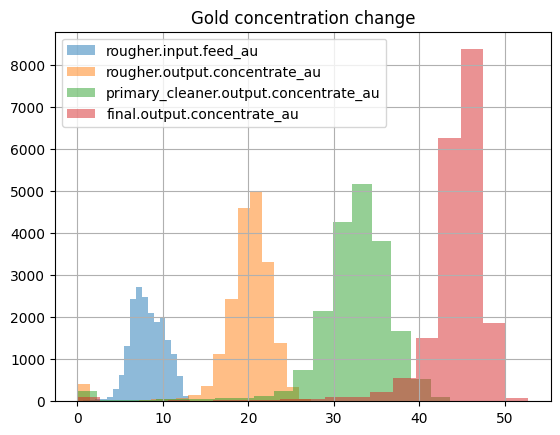

In [14]:
# %%
plot_concentrate_progress('au')
plt.title('Gold concentration change')


Text(0.5, 1.0, 'Silver concentration change')

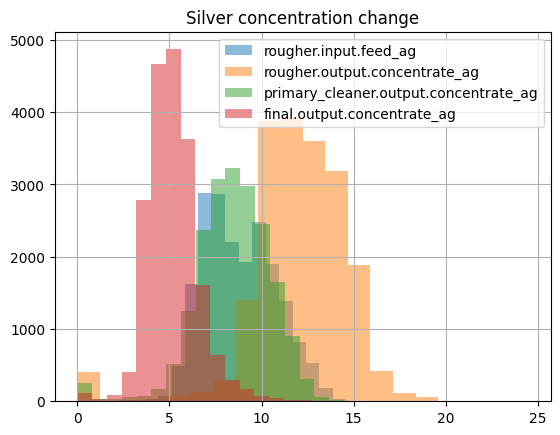

In [15]:
# %%
plot_concentrate_progress('ag')
plt.title('Silver concentration change')


Text(0.5, 1.0, 'Lead concentration change')

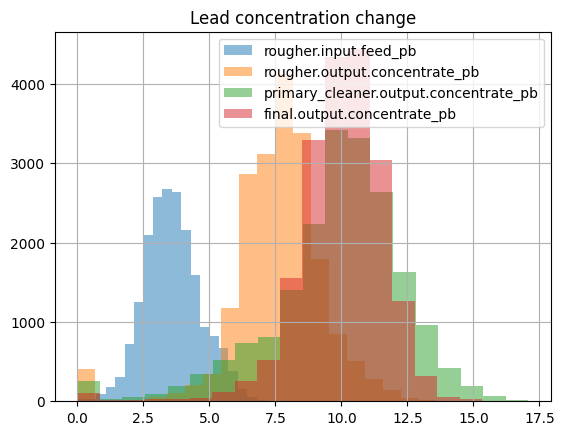

In [16]:
# %%
plot_concentrate_progress('pb')
plt.title('Lead concentration change')


 It is obvious that as the process progresses, the proportion of gold `Au` in the concentrate increases significantly, the proportion of silver `Ag` decreases (mainly during the second purification), and the proportion of lead `Pb` increases (mainly during flotation).

 ### Particle size comparison for train and test

In [17]:
# %%
def filter_outliers(series):
    return series[series.between(series.quantile(0.01), series.quantile(0.99))]

def compare_train_test_feature(feature):
    filter_outliers(df_train[feature]).plot.kde()
    filter_outliers(df_test[feature]).plot.kde()
    plt.legend(['train', 'test'])


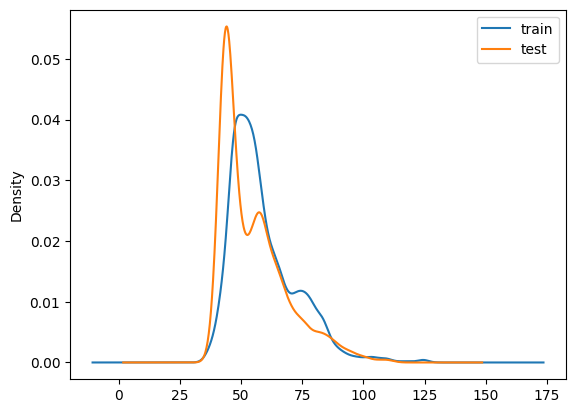

In [18]:
# %%
compare_train_test_feature('rougher.input.feed_size')


 It is obvious that at the start of the process, the particle size is intended to be kept at 55-60 microns. There is a slight shift from the normal distribution towards larger particle size. Also for the test set, there is a greater significance of very small particles. Visually, there is now significant difference between train and test.

 ### Total amount of substance

<Axes: >

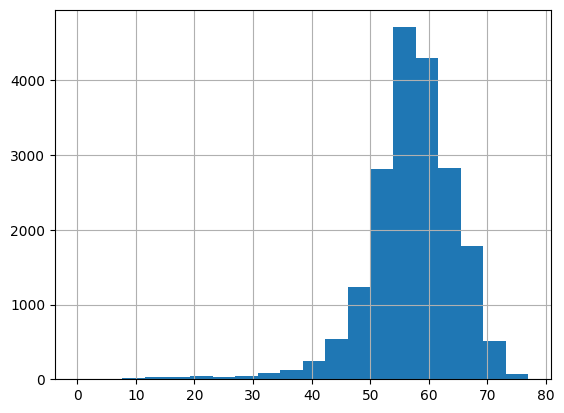

In [19]:
# %%
features_input_concentrate = [
    'rougher.input.feed_au',
    'rougher.input.feed_ag',
    'rougher.input.feed_pb',
    'rougher.input.feed_sol',
]

df_full[features_input_concentrate].sum(1).hist(bins=20)


<Axes: >

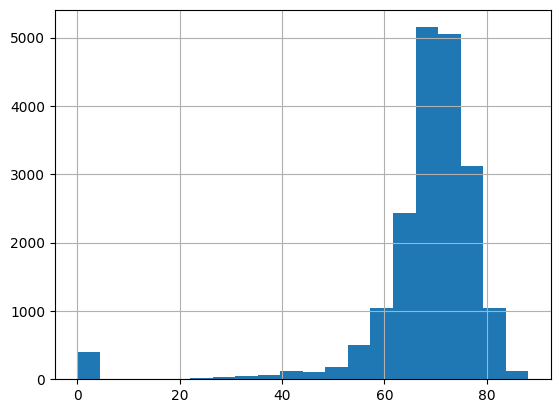

In [20]:
# %%
features_rough_concentrate = [
    'rougher.output.concentrate_au',
    'rougher.output.concentrate_ag',
    'rougher.output.concentrate_pb',
    'rougher.output.concentrate_sol',
]

df_full[features_rough_concentrate].sum(1).hist(bins=20)


<Axes: >

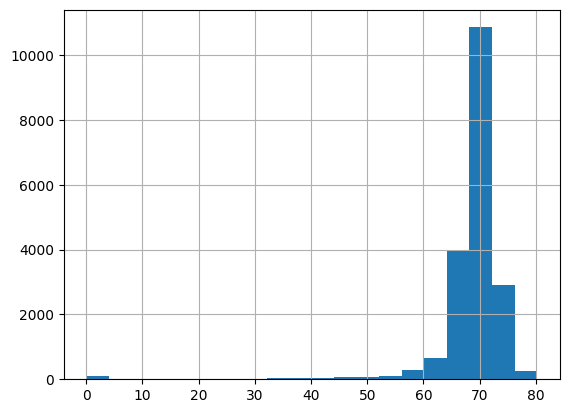

In [21]:
# %%
features_final_concentrate = [
    'final.output.concentrate_au',
    'final.output.concentrate_ag',
    'final.output.concentrate_pb',
    'final.output.concentrate_sol',
]

df_full[features_final_concentrate].sum(1).hist(bins=20)


 There are a significant number of observations close or equal to zero. Most likely this is due to the failure of the measuring equipment. Such observations must be removed from the data.



 The model will be used to select equipment parameters, so the failure examples are not interesting for modeling. They need to be removed not only from the training set, but also from the test set.

In [22]:
# %%
THRESHOLD = 0.01

df_train = df_train[df_train[features_input_concentrate].sum(1) > THRESHOLD]
df_train = df_train[df_train[features_rough_concentrate].sum(1) > THRESHOLD]
df_train = df_train[df_train[features_final_concentrate].sum(1) > THRESHOLD]

print(df_train.shape)

df_full_test = df_full.loc[df_test.index]
df_test = df_test[df_full_test[features_input_concentrate].sum(1) > THRESHOLD]
df_test = df_test[df_full_test[features_rough_concentrate].sum(1) > THRESHOLD]
df_test = df_test[df_full_test[features_final_concentrate].sum(1) > THRESHOLD]

print(df_test.shape)


(13795, 86)
(5154, 52)


/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_37421/3352375620.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_test = df_test[df_full_test[features_final_concentrate].sum(1) > THRESHOLD]


 The sample sizes have not reduced greatly. Can proceed to modeling.

 # 3. Model

 ### Sample forming

In [23]:
# %%
features = df_test.columns.values


In [24]:
# %%
targets = ['rougher.output.recovery', 'final.output.recovery']


In [25]:
# %%
features_train = df_train[features].reset_index(drop=True)
target_train = df_train[targets].reset_index(drop=True)
target_train.columns = [0, 1]


In [26]:
# %%
target_train.head()


,0,1
0,87.107763,70.541216
1,86.843261,69.266198
2,86.842308,68.116445
3,87.226430,68.347543
4,86.688794,66.927016


In [27]:
# %%
features_test = df_test[features].reset_index(drop=True)
target_test = df_full[targets].loc[df_test.index].reset_index(drop=True)
target_test.columns = [0, 1]


 ### Calculation sMAPE

In [28]:
# %%
def smape(y_true, y_pred):
    error = (y_true - y_pred).abs()
    scale = (y_true.abs() + y_pred.abs()) / 2
    
    return (error / scale).mean()


def smape_weighted(y_true, y_pred):
    rougher = smape(y_true[0], y_pred[0])
    final = smape(y_true[1], y_pred[1])
    return 0.25 * rougher + 0.75 * final


In [29]:
# %%
pred_median = target_train.copy()
pred_median[0] = target_train[0].median()
pred_median[1] = target_train[1].median()
print(smape_weighted(target_train, pred_median))

pred_median = target_test.copy()
pred_median[0] = target_train[0].median()
pred_median[1] = target_train[1].median()
print(smape_weighted(target_test, pred_median))


0.09468182190998983
0.07363660673394497


 ### Training and validation of models

In [30]:
# %%
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

def score_model(model, cv=4):
    scores = []
    for subtrain_index, valid_index in KFold(n_splits=cv).split(features_train):
        features_subtrain = features_train.loc[subtrain_index].reset_index(drop=True)
        target_subtrain = target_train.loc[subtrain_index].reset_index(drop=True)
        features_valid = features_train.loc[valid_index].reset_index(drop=True)
        target_valid = target_train.loc[valid_index].reset_index(drop=True)
        
        model.fit(features_subtrain, target_subtrain)
        pred_valid = pd.DataFrame(model.predict(features_valid))
        
        scores.append(smape_weighted(target_valid, pred_valid))
        
    return pd.Series(scores).mean()


In [31]:
# %%
model = LinearRegression()
lr_score = score_model(model)
print("LR:", lr_score)


LR: 0.10183451659002765


In [32]:
# %%

for depth in range(1, 5):
    model = RandomForestRegressor(max_depth=depth, n_estimators=50, random_state=12345)
    score = score_model(model)
    print("RF, depth =", depth, "score =", score)


RF, depth = 1 score = 0.1024321473429751
RF, depth = 2 score = 0.09860917674257262
RF, depth = 3 score = 0.09441888114997743
RF, depth = 4 score = 0.09417854896125977


 ### Model testing using the test sample

In [33]:
# %%

model = RandomForestRegressor(max_depth=4, n_estimators=50, random_state=12345)
model.fit(features_train, target_train)

pred = pd.DataFrame(model.predict(features_train))
print("train:", smape_weighted(target_train, pred))

pred = pd.DataFrame(model.predict(features_test))
print("test:", smape_weighted(target_test, pred))


train: 0.07083750375059525
test: 0.07175127743463836


In [34]:
# %%



